# Config

In [1]:
# Libraries
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

import os
from dotenv import load_dotenv

from entsoe import EntsoePandasClient

load_dotenv()

# ENTSOE Token
entsoe_token = os.getenv("ENTSOE_API_TOKEN")

# ENTSOE Client
entsoe_client = EntsoePandasClient(api_key=entsoe_token)

In [2]:
# Location
country_capital = "Madrid"
country_code = "ES"


# Period
today = pd.Timestamp.now(
    tz=f"Europe/{country_capital}"
).normalize()

yesterday=(pd.Timestamp.now(tz=f"Europe/{country_capital}")
    .normalize()
    - pd.Timedelta(days=1)
)
last_week=(pd.Timestamp.now(tz=f"Europe/{country_capital}")
    .normalize()
    - pd.Timedelta(days=7)
)


start=last_week
end=today

In [3]:
# Query
df = entsoe_client.query_generation_import(
    country_code=country_code,
    start=last_week,
    end=today)

# EDA

In [4]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 672 entries, 2026-09-05 00:00:00+02:00 to 2026-09-11 23:45:00+02:00
Freq: 15min
Data columns (total 17 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   (Generation, Biomass)                          672 non-null    float64
 1   (Generation, Energy storage)                   672 non-null    float64
 2   (Generation, Fossil Gas)                       672 non-null    float64
 3   (Generation, Fossil Hard coal)                 672 non-null    float64
 4   (Generation, Fossil Oil)                       672 non-null    float64
 5   (Generation, Hydro Pumped Storage)             672 non-null    float64
 6   (Generation, Hydro Run-of-river and poundage)  672 non-null    float64
 7   (Generation, Hydro Water Reservoir)            672 non-null    float64
 8   (Generation, Nuclear)                          672 non-null    float64
 9   (Gen

In [5]:
df.head()

Generation                            \
                             Biomass Energy storage Fossil Gas   
2026-09-05 00:00:00+02:00      412.0            0.0    14264.0   
2026-09-05 00:15:00+02:00      408.0            0.0    14292.0   
2026-09-05 00:30:00+02:00      412.0            0.0    14000.0   
2026-09-05 00:45:00+02:00      412.0            0.0    13812.0   
2026-09-05 01:00:00+02:00      416.0            0.0    13772.0   

                                                                            \
                          Fossil Hard coal Fossil Oil Hydro Pumped Storage   
2026-09-05 00:00:00+02:00            152.0       28.0               1700.0   
2026-09-05 00:15:00+02:00            128.0       28.0               1592.0   
2026-09-05 00:30:00+02:00            100.0       28.0               1624.0   
2026-09-05 00:45:00+02:00             64.0       28.0               1616.0   
2026-09-05 01:00:00+02:00              0.0       28.0               1460.0   

                                                           \
                          Hydro Run-of-river and poundage   
2026-09-05 00:00:00+02:00                           460.0   
2026-09-05 00:15:00+02:00                           452.0   
2026-09-05 00:30:00+02:00                           452.0   
2026-09-05 00:45:00+02:00                           440.0   
2026-09-05 01:00:00+02:00                           436.0   

                                                                               \
                          Hydro Water Reservoir Nuclear Other Other renewable   
2026-09-05 00:00:00+02:00                2380.0  5940.0  12.0            68.0   
2026-09-05 00:15:00+02:00                2048.0  5940.0  12.0            68.0   
2026-09-05 00:30:00+02:00                2068.0  5944.0  12.0            68.0   
2026-09-05 00:45:00+02:00                1752.0  5944.0  16.0            64.0   
2026-09-05 01:00:00+02:00                1256.0  5948.0  16.0            64.0   

                                                       Import                
                           Solar  Waste Wind Onshore       FR   PT      sum  
2026-09-05 00:00:00+02:00  236.0  260.0       3480.0  3075.92  0.0  3075.92  
2026-09-05 00:15:00+02:00  228.0  260.0       3580.0  3086.00  0.0  3086.00  
2026-09-05 00:30:00+02:00  228.0  260.0       3792.0  2919.64  0.0  2919.64  
2026-09-05 00:45:00+02:00  204.0  260.0       3920.0  2818.96  0.0  2818.96  
2026-09-05 01:00:00+02:00  184.0  260.0       4092.0  2855.84  0.0  2855.84

In [6]:
df.columns

MultiIndex([('Generation',                         'Biomass'),
            ('Generation',                  'Energy storage'),
            ('Generation',                      'Fossil Gas'),
            ('Generation',                'Fossil Hard coal'),
            ('Generation',                      'Fossil Oil'),
            ('Generation',            'Hydro Pumped Storage'),
            ('Generation', 'Hydro Run-of-river and poundage'),
            ('Generation',           'Hydro Water Reservoir'),
            ('Generation',                         'Nuclear'),
            ('Generation',                           'Other'),
            ('Generation',                 'Other renewable'),
            ('Generation',                           'Solar'),
            ('Generation',                           'Waste'),
            ('Generation',                    'Wind Onshore'),
            (    'Import',                              'FR'),
            (    'Import',                             

In [7]:
df.describe().T.round(2)

count     mean       std     min  \
Generation Biomass                          672.0   404.96     42.42   268.0   
           Energy storage                   672.0     2.19      7.50   -20.0   
           Fossil Gas                       672.0  7813.17   3773.20  2524.0   
           Fossil Hard coal                 672.0    73.01     91.32     0.0   
           Fossil Oil                       672.0    17.80      5.51    12.0   
           Hydro Pumped Storage             672.0   140.20   2062.08 -3868.0   
           Hydro Run-of-river and poundage  672.0   413.30     68.28   292.0   
           Hydro Water Reservoir            672.0  1300.70    924.07   160.0   
           Nuclear                          672.0  6412.02    552.67  5400.0   
           Other                            672.0    13.48      2.64     4.0   
           Other renewable                  672.0    60.06      3.42    52.0   
           Solar                            672.0  9720.76  10628.32    44.0   
           Waste                            672.0   238.93     17.91   188.0   
           Wind Onshore                     672.0  4558.08   2912.80   392.0   
Import     FR                               672.0  1617.68   1322.82     0.0   
           PT                               672.0    14.69     78.11     0.0   
           sum                              672.0  1632.37   1323.44     0.0   

                                               25%      50%       75%  \
Generation Biomass                           384.0   412.00    436.00   
           Energy storage                      0.0     0.00      0.00   
           Fossil Gas                       3770.0  8094.00  11028.00   
           Fossil Hard coal                    0.0     0.00    164.00   
           Fossil Oil                         12.0    16.00     20.00   
           Hydro Pumped Storage            -1861.0  1060.00   1668.00   
           Hydro Run-of-river and poundage   360.0   408.00    452.00   
           Hydro Water Reservoir             532.0  1106.00   1786.00   
           Nuclear                          5968.0  6536.00   6952.00   
           Other                              12.0    12.00     16.00   
           Other renewable                    56.0    60.00     64.00   
           Solar                             324.0  1638.00  21689.00   
           Waste                             224.0   240.00    252.00   
           Wind Onshore                     2487.0  3488.00   6848.00   
Import     FR                                  0.0  2151.52   2843.81   
           PT                                  0.0     0.00      0.00   
           sum                                 0.0  2151.52   2846.85   

                                                 max  
Generation Biomass                            476.00  
           Energy storage                      40.00  
           Fossil Gas                       16064.00  
           Fossil Hard coal                   220.00  
           Fossil Oil                          28.00  
           Hydro Pumped Storage              2968.00  
           Hydro Run-of-river and poundage    604.00  
           Hydro Water Reservoir             4048.00  
           Nuclear                           6996.00  
           Other                               16.00  
           Other renewable                     68.00  
           Solar                            27348.00  
           Waste                              276.00  
           Wind Onshore                     12052.00  
Import     FR                                3423.44  
           PT                                 682.72  
           sum                               3675.92

In [8]:
# GENERATION by source in MWh
generation_mwh = df.xs(
    "Generation", 
    axis=1, 
    level=0
) * 0.25

generation_mwh

,Biomass,Energy storage,Fossil Gas,Fossil Hard coal,Fossil Oil,Hydro Pumped Storage,Hydro Run-of-river and poundage,Hydro Water Reservoir,Nuclear,Other,Other renewable,Solar,Waste,Wind Onshore
2026-09-05 00:00:00+02:00,103.0,0.0,3566.0,38.0,7.0,425.0,115.0,595.0,1485.0,3.0,17.0,59.0,65.0,870.0
2026-09-05 00:15:00+02:00,102.0,0.0,3573.0,32.0,7.0,398.0,113.0,512.0,1485.0,3.0,17.0,57.0,65.0,895.0
2026-09-05 00:30:00+02:00,103.0,0.0,3500.0,25.0,7.0,406.0,113.0,517.0,1486.0,3.0,17.0,57.0,65.0,948.0
2026-09-05 00:45:00+02:00,103.0,0.0,3453.0,16.0,7.0,404.0,110.0,438.0,1486.0,4.0,16.0,51.0,65.0,980.0
2026-09-05 01:00:00+02:00,104.0,0.0,3443.0,0.0,7.0,365.0,109.0,314.0,1487.0,4.0,16.0,46.0,65.0,1023.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-09-11 22:45:00+02:00,109.0,0.0,2820.0,0.0,5.0,509.0,124.0,383.0,1743.0,2.0,17.0,153.0,52.0,2340.0
2026-09-11 23:00:00+02:00,108.0,0.0,2694.0,0.0,5.0,434.0,120.0,372.0,1742.0,2.0,17.0,152.0,51.0,2373.0
2026-09-11 23:15:00+02:00,107.0,0.0,2453.0,0.0,5.0,454.0,119.0,443.0,1743.0,2.0,16.0,151.0,51.0,2354.0
2026-09-11 23:30:00+02:00,109.0,0.0,2329.0,0.0,5.0,471.0,117.0,381.0,1743.0,2.0,16.0,151.0,50.0,2340.0


In [9]:
# IMPORT by source in MWh
import_mwh = df.xs(
    "Import", 
    axis=1, 
    level=0
).drop(columns="sum") * 0.25

import_mwh

,FR,PT
2026-09-05 00:00:00+02:00,768.98,0.0
2026-09-05 00:15:00+02:00,771.50,0.0
2026-09-05 00:30:00+02:00,729.91,0.0
2026-09-05 00:45:00+02:00,704.74,0.0
2026-09-05 01:00:00+02:00,713.96,0.0
...,...,...
2026-09-11 22:45:00+02:00,0.00,0.0
2026-09-11 23:00:00+02:00,0.00,0.0
2026-09-11 23:15:00+02:00,0.00,0.0
2026-09-11 23:30:00+02:00,0.00,0.0


In [10]:
# Daily GENERATION by source in MWh
daily_generation_mwh = df.xs(
    "Generation", 
    axis=1, 
    level=0
).resample("D").sum()  * 0.25

daily_generation_mwh

,Biomass,Energy storage,Fossil Gas,Fossil Hard coal,Fossil Oil,Hydro Pumped Storage,Hydro Run-of-river and poundage,Hydro Water Reservoir,Nuclear,Other,Other renewable,Solar,Waste,Wind Onshore
2026-09-05 00:00:00+02:00,9937.0,33.0,209010.0,111.0,450.0,7623.0,9800.0,34520.0,136055.0,356.0,1499.0,180333.0,6233.0,104102.0
2026-09-06 00:00:00+02:00,9307.0,32.0,190296.0,0.0,427.0,-1231.0,9350.0,25955.0,134153.0,356.0,1398.0,216249.0,5859.0,68136.0
2026-09-07 00:00:00+02:00,9070.0,47.0,233357.0,1397.0,437.0,14297.0,9943.0,39226.0,152159.0,328.0,1394.0,259991.0,5797.0,52283.0
2026-09-08 00:00:00+02:00,10164.0,39.0,206770.0,4841.0,479.0,4128.0,9886.0,32897.0,157121.0,373.0,1431.0,242703.0,5615.0,127553.0
2026-09-09 00:00:00+02:00,9182.0,74.0,154784.0,4229.0,355.0,-10275.0,9302.0,21141.0,163296.0,303.0,1404.0,228080.0,5292.0,227905.0
2026-09-10 00:00:00+02:00,9957.0,89.0,158033.0,1687.0,410.0,150.0,10439.0,31397.0,166976.0,294.0,1446.0,259051.0,5792.0,87961.0
2026-09-11 00:00:00+02:00,10416.0,54.0,160363.0,0.0,432.0,8861.0,10715.0,33382.0,167460.0,254.0,1518.0,246680.0,5553.0,97818.0


In [11]:
# Daily IMPORT by location source in MWh
daily_import_mwh = (
    df.xs("Import", axis=1, level=0)
    .drop(columns="sum")
    .resample("D")
    .sum()  
    * 0.25
)

daily_import_mwh

,FR,PT
2026-09-05 00:00:00+02:00,67251.97,0.00
2026-09-06 00:00:00+02:00,58091.92,1074.32
2026-09-07 00:00:00+02:00,46633.62,5.81
2026-09-08 00:00:00+02:00,40915.65,151.15
2026-09-09 00:00:00+02:00,12572.73,0.00
2026-09-10 00:00:00+02:00,26607.61,1237.03
2026-09-11 00:00:00+02:00,19696.43,0.00


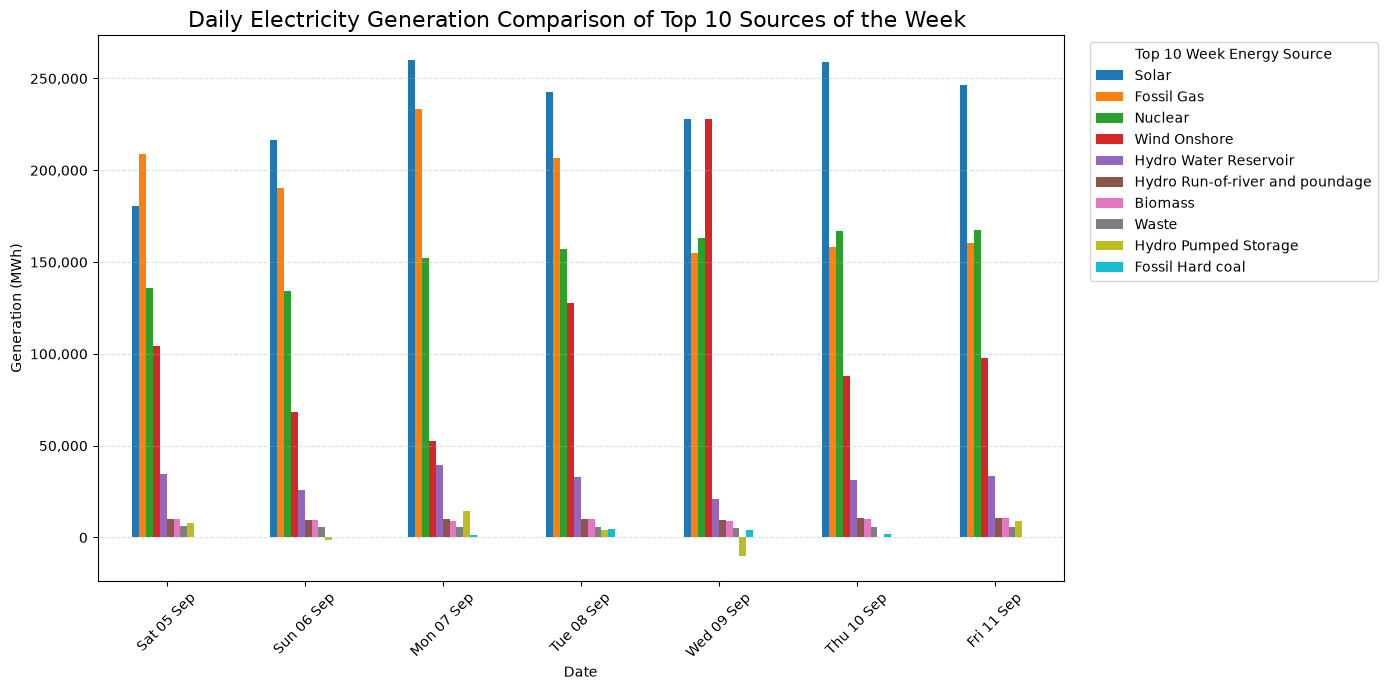

In [12]:
# Plot -> bar chart of daily top_n source GENERATION 

top_n = 10 # find the n largest generation sources

top_sources = (
    daily_generation_mwh
    .sum()
    .sort_values(ascending=False)
    .head(top_n)
    .index
)


fig, ax = plt.subplots(figsize=(14, 7))

daily_generation_mwh[top_sources].plot(
    kind="bar",
    ax=ax
)

ax.set_title(
    f"Daily Electricity Generation Comparison of Top {top_n} Sources of the Week ",
    fontsize=16,
    # fontweight="bold"
)

ax.set_xlabel("Date")
ax.set_xticklabels(
    daily_generation_mwh.index.strftime("%a %d %b"),
    rotation=0
)


ax.set_ylabel("Generation (MWh)")
ax.yaxis.set_major_formatter( FuncFormatter(lambda x, pos: f"{x:,.0f}") )

ax.legend(
    title=f"Top {top_n} Week Energy Source",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



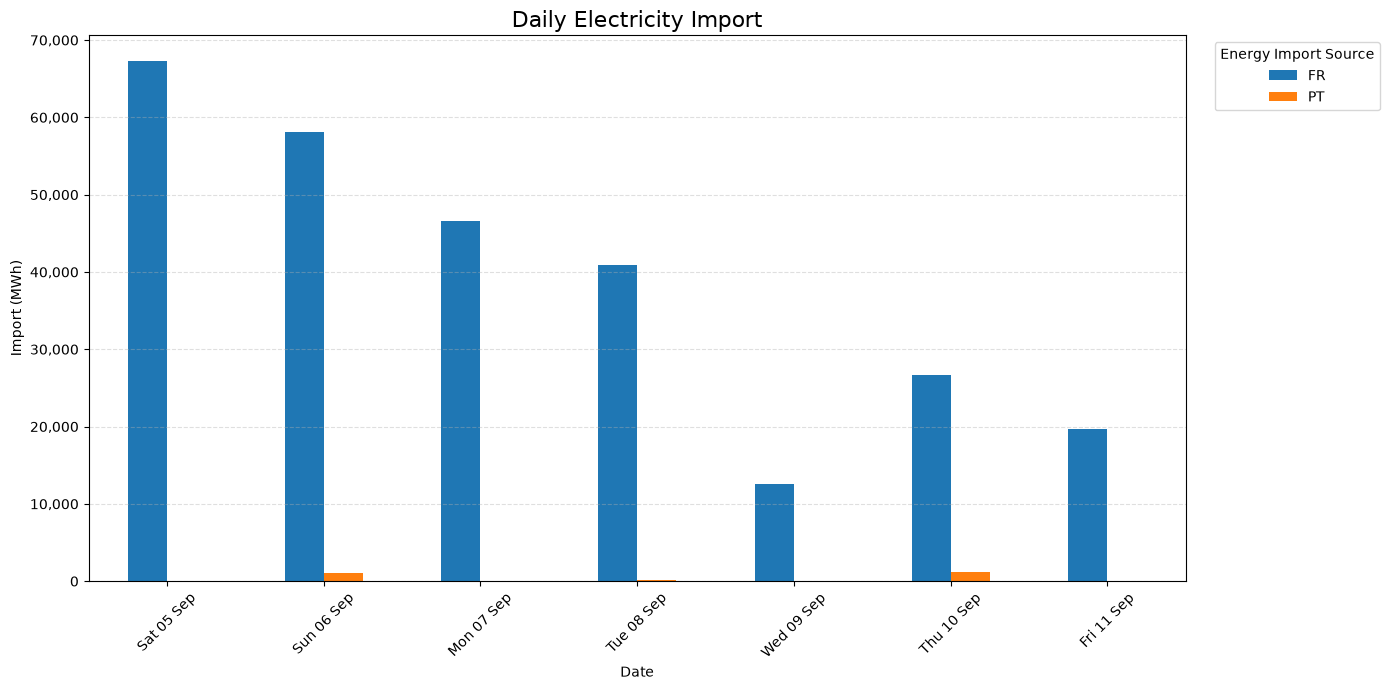

In [13]:
# Plot -> bar chart of daily IMPORT 

fig, ax = plt.subplots(figsize=(14, 7))

daily_import_mwh.plot(
    kind="bar",
    ax=ax
)

ax.set_title(
    f"Daily Electricity Import",
    fontsize=16,
)

ax.set_xlabel("Date")
ax.set_xticklabels(
    daily_import_mwh.index.strftime("%a %d %b"),
    rotation=0
)


ax.set_ylabel("Import (MWh)")
ax.yaxis.set_major_formatter( FuncFormatter(lambda x, pos: f"{x:,.0f}") )

ax.legend(
    title=f"Energy Import Source",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

